# iTRAILS results

Loads the outputs produced by the workflow (`gwf run` in the repository root) and
gives a first look at each analysis: the fitted model parameters, the Viterbi
segmentation of the alignment into gene-tree states, and the posterior state
probabilities along the alignment.

The notebook is executed by the workflow itself once all upstream targets are
done, so it simply discovers whatever analyses exist under `steps/itrails/`
(each analysis has one subfolder per step: `split/`, `optimize/`, `viterbi/`,
`posterior/`, `concat/`).

In [1]:
import vscodenb
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import demesdraw
import msprime
from pprint import pprint
from functools import partial
from IPython.display import display, SVG
import graphviz
import random
import time
from statistics import mean

In [2]:
class TreeNode:
    
    def __init__(self, data):
        self.data = data
        self.left = None
        self.right = None
        self.parent = None
        self.idx = None

def update_parents(node):
    if node.left and node.right:
        update_parents(node.left)
        update_parents(node.right)
        node.left.parent = node
        node.right.parent = node

def from_tuples(t):
    """
    Generates a tree from nested tuples and returns a list of nodes in "pre-order". I.e.
    first node is the root.

    Parameters
    ----------
    t : 
        Nested tuples.

    Returns
    -------
    :
        List of nodes in pre-order. Root has index 0.
    """    

    nodes = []
    
    def _from_tuples(t):    
        if type(t) is not tuple:
            node = TreeNode(t)
            node.idx = len(nodes)
            nodes.append(node)
            return node
        node = TreeNode(t)
        node.idx = len(nodes)
        nodes.append(node)        
        node.left = _from_tuples(t[0])
        node.right = _from_tuples(t[1])
        return node

    root = _from_tuples(t)
    update_parents(root)
    return nodes

def inorder(root):
    if root is not None:
        inorder(root.left)
        print(root.data)
        inorder(root.right)

def preorder(root):
    if root is not None:
        print(root.data)
        preorder(root.left)
        preorder(root.right)

def postorder(root):
    if root is not None:
        postorder(root.left)
        postorder(root.right)
        print(root.data)

def show_tree(root):
    dot = graphviz.Digraph()
    dot.node(str(root.data))

    def add_nodes_edges(node):
        if node.left:
            dot.node(str(node.left.data))
            dot.edge(str(node.data), str(node.left.data))
            add_nodes_edges(node.left)
        if node.right:
            dot.node(str(node.right.data))
            dot.edge(str(node.data), str(node.right.data))
            add_nodes_edges(node.right)

    add_nodes_edges(root)
    return dot        

In [3]:
def _postorder_iter(root): 
    if root is None: return		
    s1 = [] 
    s2 = [] 
    s1.append(root) 
    while s1: 
        node = s1.pop() 
        s2.append(node) 
        if node.left: 
            s1.append(node.left) 
        if node.right: 
            s1.append(node.right) 
    while s2: 
    	yield s2.pop() 

def postorder(root, f_collect, f_break=None):
    """
    Postorder traversal using iteration and stacks

    Parameters
    ----------
    root : 
        Node (tree) with a data atrribute as well as left and right attributes that are
        also nodes.
    f_collect : 
        Function aggregating data, takes data from left and right child as arguments.
    f_break : 
        Function for breaking the traversal and returning a value, by default None. The
        function must accept the current node and accumulated node data as positional

    Returns
    -------
    :
        Data collected using `f_collect`. If `f_break` is also provided, returns None or
        whatever non-None value `f_break` first returns.
    """
    stack = []
    for node in _postorder_iter(root):
        if node.left or node.right:
            left = stack.pop()
            right = stack.pop()
            data = f_collect(left, right)
            stack.append(data)
        else:
            data = node.data
            stack.append(data) # leaf            
        if f_break:
            val = f_break(node, data)
            if val is not None: return val
    if f_break:
        return None
    return stack[0]

def leaf_count(a, b):
    return a + b

def leaves(a, b):
    if not isinstance(a, list):
        a = [a]
    if not isinstance(b, list):
        b = [b]
    return a + b #.union(b)

def breaker(node, data, match):
    if not (node.left or node.right):
        return None
    inter = set(match).intersection(set(data))
    if len(inter) == len(match):
        return node.idx

# stack = postorder(hcg_tree, leaves) 
# print(stack)
# stack = postorder(hgo_tree, leaves) 
# print(stack)


In [4]:
hcg_tree_nodes = from_tuples((('Human', 'Chimp'), 'Gorilla'))
hcg_tree = hcg_tree_nodes[0]
hgo_tree_nodes = from_tuples((('Human', 'Gorilla'), 'Orang'))
hgo_tree = hgo_tree_nodes[0]

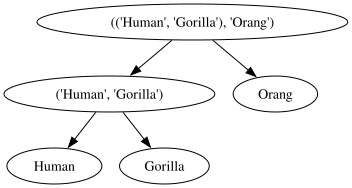

In [5]:
show_tree(hgo_tree)

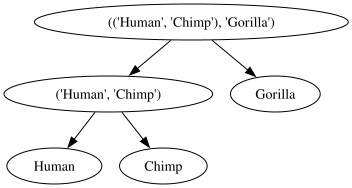

In [6]:
show_tree(hcg_tree)

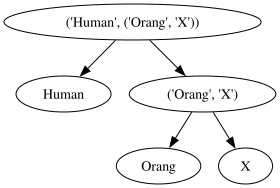

In [7]:
hox_tree_nodes = from_tuples(('Human', ('Orang', "X")))
hox_tree = hox_tree_nodes[0]
show_tree(hox_tree)

In [8]:
def idx_postorder(nodes):

    idx_list = []

    def _idx_postorder(root):
        if root is not None:
            _idx_postorder(root.left)
            _idx_postorder(root.right)
            idx_list.append(root.idx)

    _idx_postorder(nodes[0])
    return idx_list
idx_postorder(hcg_tree_nodes)

[2, 3, 1, 4, 0]

In [ ]:
hcg_tree_nodes = from_tuples((('Human', 'Chimp'), 'Gorilla'))
hcg_tree = hcg_tree_nodes[0]
hgo_tree_nodes = from_tuples((('Human', 'Gorilla'), 'Orang'))
hgo_tree = hgo_tree_nodes[0]

hox_tree_nodes = from_tuples(('Human', ('Orang', "X")))
hox_tree = hox_tree_nodes[0]

a_nodes = hcg_tree_nodes
b_nodes = hgo_tree_nodes

# a_nodes = hgo_tree_nodes
# b_nodes = hox_tree_nodes
#b_nodes = hcg_tree_nodes

a_leaves = set(postorder(a_nodes[0], leaves))
b_leaves = set(postorder(b_nodes[0], leaves))

sister_nodes = []
for i in idx_postorder(a_nodes):
    node = a_nodes[i]
    clade = set(postorder(node, leaves))
    clade = clade.intersection(a_leaves)
    sister_idx = postorder(b_nodes[0], leaves, partial(breaker, match=clade))
    if sister_idx in sister_nodes: 
        print(sister_idx)
        # cannot use twice
        sister_idx = None
    sister_nodes.append(sister_idx)
print(sister_nodes)

for i, s in enumerate(sister_nodes):
    if s is not None:
        print(a_nodes[i].data, 'overlaps', b_nodes[s].data)
        # b_nodes[s].data = a_nodes[i].data
        # b_nodes[s].left = a_nodes[i].left
        # b_nodes[s].right = a_nodes[i].right
        # show_tree(b_nodes[0])
        a_nodes[i].data = b_nodes[s].data
        a_nodes[i].left = b_nodes[s].left
        a_nodes[i].right = b_nodes[s].right
        show_tree(a_nodes[0])

2
None
2
None
[2, None, None, None, None]
(('Human', 'Gorilla'), 'Orang') overlaps ('Orang', 'X')


## Find ALL overlaps and use the onw with largest intersection / size

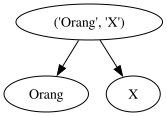

In [12]:
show_tree(a_nodes[0])



In [ ]:

# stack = postorder_find_other(hcg_tree, leaves, set(['Human', 'Orang']))
# print(stack)


## Reading / visualizing results

In [2]:
def read_estimates(analysis):

    estimates = []
    path = analysis / 'optimize'
    for best_model in sorted(path.glob('*.best_model.yaml')):
        with open(best_model) as f:
            best = yaml.safe_load(f)
        names = dict(zip(['A', 'B', 'C', 'D'], best['settings']['species_list']))
        names['1'] = names['A'] + '-' + names['B']
        names['2'] = names['1'] + '-' + names['C']
        names['upper'] = names['2'] + '-' + names['D']
        T = 0
        estimates.append(best)
    param_map = {}
    for k, v in sorted(estimates[-1]['optimized_parameters'].items()):        
        if k.startswith('N_'):
            param_map[k] = f"N {'-'.join([names[c] for c in k[2:]])}"
        if k.startswith('t_'):
            T += v
            param_map[k] = f"T {names[k[2:]]}"
        if k == 'r':
            param_map[k] = 'Recomb. rate'

    return estimates, param_map

def print_estimates(analysis):
    estimates, param_map = read_estimates(analysis)
    print(f"{analysis.name}")
    for e in estimates: 
        T = 0
        for k, v in sorted(e['optimized_parameters'].items()):
            k = f"{param_map.get(k, k) +':':<35}"
            v = f"{int(v):>7,}" if v > 1 else f"{v:>7,.2g}"
            print(k + v)

def _get_optim_histories(analysis, window=None):
    path = analysis / 'optimize'
    paths = sorted(path.glob('*.optimization_history.csv'))
    if window is not None:
        paths = [paths[window]]
    df_list = []
    for i, path in enumerate(paths):
        _df = pd.read_csv(path)
        df_list.append(_df.assign(win=i))
        df = pd.concat(df_list)
    return df

def plot_param_fit(analysis, window=None, **kwargs):
    df = _get_optim_histories(analysis, window=window)
    plot_df = df.drop(columns=['time', 'loglik']).melt(id_vars=['win', 'n_eval'])
    g = sns.FacetGrid(plot_df, col="variable", hue='win', sharey=False, aspect=2, height=2, col_wrap=2)
    g.map(sns.lineplot, 'n_eval', 'value', **kwargs)
    g.set_titles(col_template="{col_name}")
    g.despine(left=True, bottom=True)

def plot_loglike(analysis, reldiff=True, ax2color='C2', ax2alpha=0.5, window=None, **kwargs):
    plot_df = _get_optim_histories(analysis, window=window)
    fig, ax = plt.subplots(figsize=(7,3))
    if reldiff:
        ax2kwargs = dict(color=ax2color, alpha=0.5)
        ax2kwargs.update(kwargs)
        ax2 = ax.twinx()  # instantiate a second Axes that shares the same x-axis
        ax2.grid(False)
        ax2.axhline(0, ls='dotted', color=ax2color, alpha=ax2alpha)
        ax2.set_ylabel('relative difference')  # we already handled the x-label with ax1
        ax2.tick_params(axis='y', color=ax2color)
    for name, df in plot_df.groupby('win'):
        if reldiff:
            ax2.plot(df.n_eval, (df.loglik - df.loglik.shift())/df.loglik, **ax2kwargs)
    ax.plot(df.n_eval, df.loglik, **kwargs)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Log likelihood')
    # sns.lineplot(df, x='n_eval', y='loglik', ax=ax)

def plot_convergence(analysis, window=None):
    fig, ax = plt.subplots(figsize=(7,3))
    df = _get_optim_histories(analysis, window=window)
    df = df.drop(columns=['time', 'loglik'])#.melt(id_vars=['win', 'n_eval'])
    df = df.set_index(['win', 'n_eval'])
    df = (df - df.min()) / (df.max() - df.min())
    # df = df - df.groupby('win').iloc[-1]
    df = df - df.groupby('win').apply(lambda df: df.iloc[-1]).mean()
    df = df.reset_index()
    plot_df = df.melt(id_vars=['win', 'n_eval'], var_name='Parameter')
    sns.lineplot(plot_df, x='n_eval', y='value', hue='Parameter', style='win', ax=ax)

    # for name, df in _df.groupby('win'):
    #     df = df.drop(columns=['time', 'loglik'])
    #     df = df.set_index('n_eval')
    #     df = (df - df.min()) / (df.max() - df.min())
    #     df = df - df.iloc[-1]
    #     df = df.reset_index()
    #     plot_df = df.melt(id_vars='n_eval', var_name='Parameter')
    #     sns.lineplot(plot_df, x='n_eval', y='value', hue='Parameter', style='win', ax=ax)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Min-max scaled and shifted')
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

def show_demography(d, ax=None):
    colored = []
    props = ['tspaint_ghost', 'tspaint_reference']
    for p in d.populations:
        if any(p.extra_metadata.get(prop, False) for prop in props):
            colored.append(p.name)
    if ax is None:
        fig, ax = plt.subplots(figsize=(7,6))
    ax.grid(False)
    ax.grid(True, axis = 'y')    
    demesdraw.tubes(msprime.Demography.to_demes(d), 
                    ax=ax,
                    colours=dict(zip(colored, list(sns.color_palette().as_hex()))),
                    # log_time=True
                    )   

                        

## Fitted model parameters

The best parameter set found by `itrails-optimize` for each analysis
(times in generations, `r` per site per generation):

In [3]:
steps_dir = Path('..') / 'steps' / 'itrails'
analyses = sorted(p for p in steps_dir.glob('*') if p.is_dir()) if steps_dir.exists() else []
if not analyses:
    print('No iTRAILS results found yet - run the workflow first (see the README).')

for analysis in analyses:
    print_estimates(analysis)  

example
N hg38-panTro5:                     53,007
N hg38-panTro5-gorGor5:            104,495
Recomb. rate:                      2.6e-09
T hg38-panTro5:                    285,923
T hg38-panTro5-gorGor5:             29,234
T hg38-panTro5-gorGor5-ponAbe2:    268,163
global_fit
N hg38-panTro5:                      5,000
N hg38-panTro5-gorGor5:            499,999
Recomb. rate:                        1e-09
T hg38-panTro5:                     29,524
T hg38-panTro5-gorGor5:              1,000
T hg38-panTro5-gorGor5-ponAbe2:      1,000
window_fits
N hg38-panTro5:                      5,000
N hg38-panTro5-gorGor5:            499,999
Recomb. rate:                        1e-09
T hg38-panTro5:                     31,713
T hg38-panTro5-gorGor5:              1,000
T hg38-panTro5-gorGor5-ponAbe2:      1,000
N hg38-panTro5:                      5,000
N hg38-panTro5-gorGor5:            499,999
Recomb. rate:                        1e-09
T hg38-panTro5:                     34,377
T hg38-panTro5-gorGor5:

In [10]:
analysis = analyses[1]
analysis.name

'global_fit'

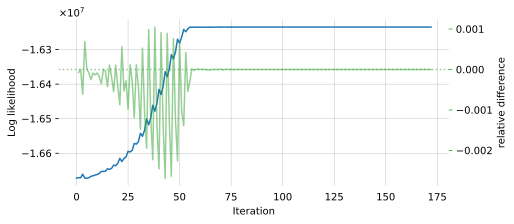

In [11]:
plot_loglike(analysis)

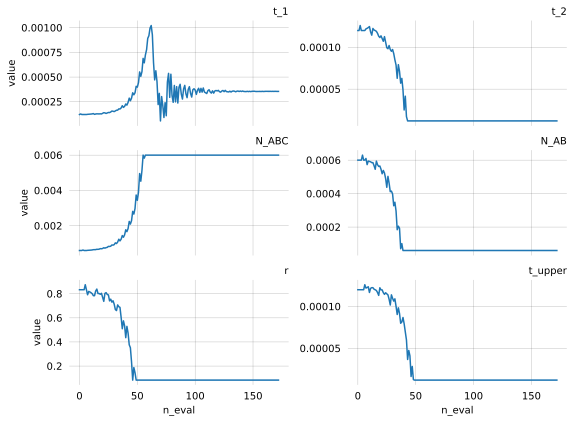

In [12]:
plot_param_fit(analysis)

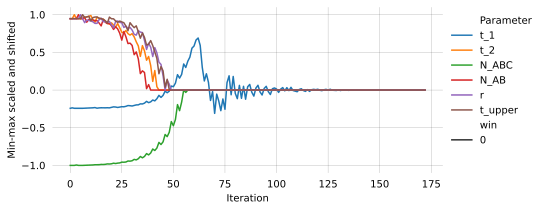

In [13]:
plot_convergence(analysis)

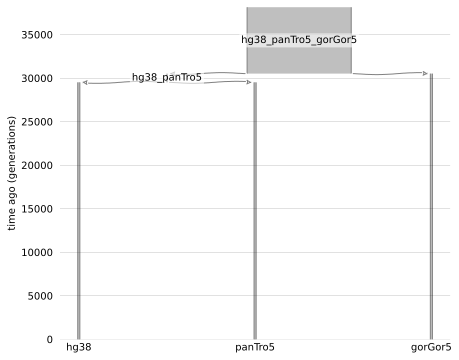

In [14]:
def demes_model(analysis, window=0):
    _estimates, param_map = read_estimates(analysis)
    best = _estimates[window]
    
    estimates = best['optimized_parameters']
    names = dict(zip(['A', 'B', 'C', 'D'], best['settings']['species_list']))

    ABC = f"{names['A']}_{names['B']}_{names['C']}" #f"{int(estimates['N_ABC'] // 1000)}"
    AB = f"{names['A']}_{names['B']}" # f"_{int(estimates['N_AB'] // 1000)}"
    A, B, C, D = names['A'], names['B'], names['C'], names['D']
    K = 3
    ref_pops = ['A', 'B', 'C']
    src_pops = ['A', 'B', 'D']

    T_ABC = estimates['t_1']+estimates['t_2'] 
    T_AB = estimates['t_1'] 
    Ne_ABC = estimates['N_ABC']
    Ne_AB = estimates['N_AB']

    Ne=10_000
    recombination_rate = 1e-8
    mutation_rate = 1.2e-8

    d = msprime.Demography()
    d.add_population(name=ABC, initial_size=Ne_ABC)
    d.add_population(name=AB, initial_size=Ne_AB)
    d.add_population(name=A, initial_size=Ne)
    d.add_population(name=B, initial_size=Ne)
    d.add_population(name=C, initial_size=Ne)
    d.add_population_split(time=T_ABC, derived=[AB, C], ancestral=ABC)
    d.add_population_split(time=T_AB, derived=[A, B], ancestral=AB)
    d.sort_events()
    return d

d = demes_model(analysis)
show_demography(d)

[{'Human'}, {'Chimp'}, {'Gorilla'}, {'Orang'}, {'Chimp', 'Human'}, {'Human', 'Gorilla'}, {'Chimp', 'Human', 'Gorilla'}, {'Human', 'Orang', 'Gorilla'}]
{'Gorilla_Human': 'Chimp_Gorilla_Human', 'Gorilla_Human_Orang': 'Chimp_Gorilla_Human_Orang'}
Chimp_Gorilla_Human ['Human', 'Gorilla']
[{'Human'}, {'Chimp'}, {'Gorilla'}, {'Orang'}, {'Gibbon'}, {'Chimp', 'Human'}, {'Chimp', 'Human', 'Gorilla'}, {'Chimp', 'Human', 'Orang', 'Gorilla'}, {'Orang', 'Human'}, {'Gibbon', 'Orang', 'Human'}]
{'Human_Orang': 'Chimp_Gorilla_Human_Orang', 'Gibbon_Human_Orang': 'Chimp_Gibbon_Gorilla_Human_Orang'}
Chimp_Gorilla_Human_Orang ['Human', 'Orang']


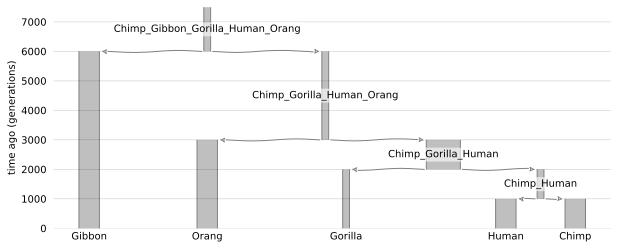

In [ ]:
def sort_name(n):
    return '_'.join(sorted(n.split('_')))

d1 = msprime.Demography()
d1.add_population(name=sort_name('Human_Chimp_Gorilla'), initial_size=20000) # <- USED
d1.add_population(name=sort_name('Human_Chimp'), initial_size=10000) # <- USED
d1.add_population(name='Human', initial_size=10000) 
d1.add_population(name='Chimp', initial_size=30000) # <- USED
d1.add_population(name='Gorilla', initial_size=10000)
d1.add_population_split(time=2000, derived=[sort_name('Human_Chimp'), 'Gorilla'], ancestral=sort_name('Human_Chimp_Gorilla'))
d1.add_population_split(time=1000, derived=['Human', 'Chimp'], ancestral=sort_name('Human_Chimp'))
d1.sort_events()

d2 = msprime.Demography()
d2.add_population(name=sort_name('Human_Gorilla_Orang'), initial_size=10000) # <- USED
d2.add_population(name=sort_name('Human_Gorilla'), initial_size=50000)
d2.add_population(name='Human', initial_size=10000)
d2.add_population(name='Gorilla', initial_size=30000)   # <- USED
d2.add_population(name='Orang', initial_size=10000)
d2.add_population_split(time=3000, derived=[sort_name('Human_Gorilla'), 'Orang'], ancestral=sort_name('Human_Gorilla_Orang'))
d2.add_population_split(time=2000, derived=['Human', 'Gorilla'], ancestral=sort_name('Human_Gorilla'))
d2.sort_events()

d3 = msprime.Demography()
d3.add_population(name=sort_name('Human_Orang_Gibbon'), initial_size=10000) # <- USED
d3.add_population(name=sort_name('Human_Orang'), initial_size=30000)
d3.add_population(name='Human', initial_size=30000)  # <- USED
d3.add_population(name='Orang', initial_size=30000)  # <- USED
d3.add_population(name='Gibbon', initial_size=30000)  # <- USED
d3.add_population_split(time=6000, derived=[sort_name('Human_Orang'), 'Gibbon'], ancestral=sort_name('Human_Orang_Gibbon'))
d3.add_population_split(time=3000, derived=['Human', 'Orang'], ancestral=sort_name('Human_Orang'))
d3.sort_events()

d4 = msprime.Demography()
d4.add_population(name=sort_name('Sumatra_Orang_Gibbon'), initial_size=10000) # <- USED
d4.add_population(name=sort_name('Sumatra_Orang'), initial_size=30000)
d4.add_population(name='Sumatra', initial_size=30000)  # <- USED
d4.add_population(name='Orang', initial_size=30000)  # <- USED
d4.add_population(name='Gibbon', initial_size=30000)  # <- USED
d4.add_population_split(time=6000, derived=[sort_name('Sumatra_Orang'), 'Gibbon'], ancestral=sort_name('Sumatra_Orang_Gibbon'))
d4.add_population_split(time=200, derived=['Sumatra', 'Orang'], ancestral=sort_name('Sumatra_Orang'))
# d4.add_population_split(time=2000, derived=[sort_name('Other_Orang'), 'Gibbon'], ancestral=sort_name('Other_Orang_Gibbon'))
# d4.add_population_split(time=1000, derived=['Other', 'Orang'], ancestral=sort_name('Other_Orang'))
d4.sort_events()

def _merge_models(models):
    d = msprime.Demography()
    events = []
    for model in models:
        spec = model.asdict()
        for event in spec['events']:
            if event['__class__'].endswith('PopulationSplit'):
                events.append(event)
    events = sorted(events, data=lambda elem: elem['time'])

    pops = []
    for event in events:
        for x in event['derived']:
            s = set(x.split('_'))
            if len(s) == 1 and s not in pops:
                pops.append(s)
    for event in events:
        pops.append(set(event['ancestral'].split('_')))

    print(pops)
    pop_mapping = {}
    for i, this in enumerate(pops):
        for other in pops[:i]:
            inter = this.intersection(other)
            union = this.union(other)
            if len(inter) and len(union) > len(this):
                pop_mapping['_'.join(sorted(this))] = '_'.join(sorted(union))
    print(pop_mapping)
    populations = {}
    for model in models:
        spec = model.asdict()
        for p in spec['populations']:
            populations[p['name']] = p

    added_pops = []
    for pop in pops:
        p = populations['_'.join(sorted(pop))]
        p_name = pop_mapping.get(p['name'], p['name'])
        if p_name not in added_pops:
            d.add_population(name=p_name, initial_size=p['initial_size'])
            added_pops.append(p_name)

    for event in events:        
        ancestral = pop_mapping.get(event['ancestral'], event['ancestral'])
        derived = [pop_mapping.get(der, der) for der in event['derived']]
        assert ancestral not in derived, (ancestral, derived)
        leaves = set([y for x in derived for y in x.split('_')])
        if set(ancestral.split('_')) == leaves:
            d.add_population_split(time=event['time'], derived=derived, ancestral=ancestral)
        else:
            print(ancestral, derived)

    d.sort_events()
    return d

def merge_models(models):
    if len(models) == 1:
        return models[0]
    m = _merge_models([models[0], models[1]])
    for i in range(2, len(models)):
        m = _merge_models([m, models[i]])
    return m


# d = merge_models([d1, d2, d3, d4])
d = merge_models([d2, d1, d3])

fig, ax = plt.subplots(figsize=(10,4))

show_demography(d, ax=ax)

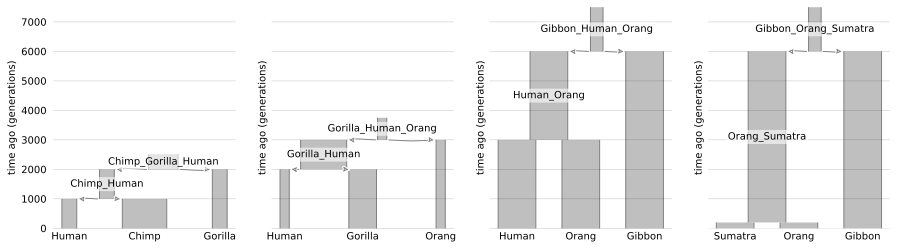

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(15,4), sharey=True)
show_demography(d1, ax=axes[0])
show_demography(d2, ax=axes[1])
show_demography(d3, ax=axes[2])
show_demography(d4, ax=axes[3])

[{'Sumatra'}, {'Orang'}, {'Human'}, {'Gorilla'}, {'Gibbon'}, {'Sumatra', 'Orang'}, {'Human', 'Gorilla'}, {'Human', 'Orang', 'Gorilla'}, {'Gibbon', 'Sumatra', 'Orang'}]
{'Gorilla_Human_Orang': 'Gorilla_Human_Orang_Sumatra', 'Gibbon_Orang_Sumatra': 'Gibbon_Gorilla_Human_Orang_Sumatra'}
Gorilla_Human_Orang_Sumatra ['Gorilla_Human', 'Orang']
Gibbon_Gorilla_Human_Orang_Sumatra ['Orang_Sumatra', 'Gibbon']


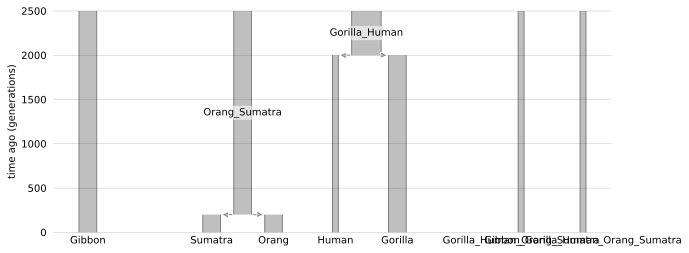

In [27]:
#d = merge_models([d3])
d = merge_models([d2, d4])
#d = merge_models([d4, d3])
fig, ax = plt.subplots(figsize=(10,4))
show_demography(d, ax=ax)

In [ ]:
d.populations

## Viterbi decoding

How much of the alignment is assigned to each hidden state (a gene-tree topology
combined with coalescence-time intervals), and the state sequence along the
genome (windowed analyses, using `concat/{name}.viterbi.csv`) or along the
largest alignment block (unwindowed analyses):

In [4]:
analysis = analyses[0]

name = analysis.name
windowed = (analysis / 'concat' / f'{name}.viterbi.csv').exists()
if windowed:
    # concatenated per-window decode; block_start + block-local position
    # places each segment on the binning-reference genome
    vit = pd.read_csv(analysis / 'concat' / f'{name}.viterbi.csv')
    vit['genome_start'] = vit['block_start'] + vit['position_start']
    vit['genome_end'] = vit['block_start'] + vit['position_end']
    # under fit: genome every window has the same state legend
    states_file = sorted((analysis / 'viterbi').glob('*.hidden_states.csv'))[0]
else:
    vit = pd.read_csv(analysis / 'viterbi' / f'{name}.viterbi.csv')
    states_file = analysis / 'viterbi' / f'{name}.hidden_states.csv'
states = pd.read_csv(states_file)
labels = states.set_index('state_idx')['shorthand_name']
vit['length'] = vit['position_end'] - vit['position_start'] + 1

vit['most_likely_state'] = vit.most_likely_state.astype(int)
vit['most_likely_state'] = pd.Categorical(vit.most_likely_state, categories=states.index.values, ordered=True)

bp_per_state = (vit.groupby('most_likely_state', observed=False)['length'].sum()
                    .rename(index=labels)#.sort_values()
                    )

In [5]:
states['a'], states['b'], states['c']= zip(*states.shorthand_name.apply(eval))
states.head()


,state_idx,topology,interval_1st_coalescent,interval_2nd_coalescent,shorthand_name,a,b,c
0,0,"({sp1,sp2},sp3)",315157.64-357526.97,315157.64-357526.97,"(0, 0, 0)",0,0,0
1,1,"({sp1,sp2},sp3)",315157.64-357526.97,357526.97-429957.80,"(0, 0, 1)",0,0,1
2,2,"({sp1,sp2},sp3)",315157.64-357526.97,429957.80-inf,"(0, 0, 2)",0,0,2
3,3,"({sp1,sp2},sp3)",357526.97-429957.80,315157.64-357526.97,"(0, 1, 0)",0,1,0
4,4,"({sp1,sp2},sp3)",357526.97-429957.80,357526.97-429957.80,"(0, 1, 1)",0,1,1


In [6]:
vit.head()

,window,chrom,block_start,src_block,Block_idx,position_start,position_end,most_likely_state,genome_start,genome_end,length
0,w0000,hg38.chr1,0,0,0,0,10922,7,0,10922,10923
1,w0000,hg38.chr1,0,0,0,10923,17091,19,10923,17091,6169
2,w0000,hg38.chr1,0,0,0,17092,18289,23,17092,18289,1198
3,w0000,hg38.chr1,0,0,0,18290,49999,8,18290,49999,31710
4,w0000,hg38.chr1,50000,1,1,0,15396,10,50000,65396,15397


In [7]:
bp_per_state

most_likely_state
(0, 0, 0)     56413
(0, 0, 1)    119189
(0, 0, 2)    259670
(0, 1, 0)         0
(0, 1, 1)     56149
(0, 1, 2)     56562
(0, 2, 0)     11761
(0, 2, 1)     41856
(0, 2, 2)    272912
(1, 0, 0)         0
(1, 0, 1)     15397
(1, 0, 2)     50974
(1, 1, 1)         0
(1, 1, 2)         0
(1, 2, 2)      1378
(2, 0, 0)         0
(2, 0, 1)         0
(2, 0, 2)      4359
(2, 1, 1)         0
(2, 1, 2)     26088
(2, 2, 2)      3006
(3, 0, 0)         0
(3, 0, 1)         0
(3, 0, 2)     11331
(3, 1, 1)         0
(3, 1, 2)     12463
(3, 2, 2)       492
Name: length, dtype: int64

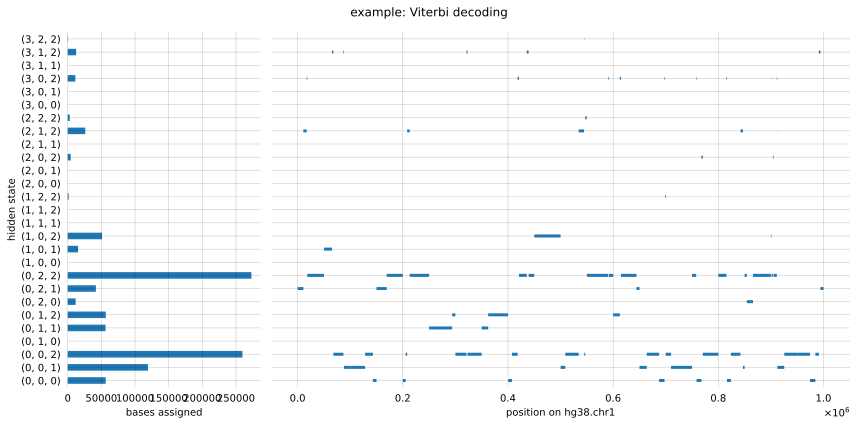

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, 
                             width_ratios=(1, 3))

bp_per_state.plot.barh(ax=axes[0], color='C0')
axes[0].set_xlabel('bases assigned')
axes[0].set_ylabel('hidden state')

if windowed:
    for seg in vit.itertuples():
        axes[1].hlines(seg.most_likely_state, seg.genome_start, seg.genome_end,
                        lw=3, color='C0')
    axes[1].set_xlabel(f"position on {vit['chrom'].iloc[0]}")
else:
    largest_block = vit.groupby('Block_idx')['length'].sum().idxmax()
    block = vit[vit['Block_idx'] == largest_block]
    for seg in block.itertuples():
        axes[1].hlines(seg.most_likely_state, seg.position_start, seg.position_end,
                        lw=3, color='C0')
    axes[1].set_xlabel(f'position in block {largest_block}')
axes[1].set_ylabel('state index')

fig.suptitle(f'{name}: Viterbi decoding')
fig.tight_layout()


## Posterior decoding

Posterior probability of every hidden state along the genome (windowed analyses,
using `concat/{name}.posterior.csv`) or along the largest alignment block
(unwindowed analyses). Positions are subsampled for plotting when the sequence
is long:

In [9]:
analysis = analyses[0]
name = analysis.name
windowed = (analysis / 'concat' / f'{name}.posterior.csv').exists()
if windowed:
    post = pd.read_csv(analysis / 'concat' / f'{name}.posterior.csv')
    prob_cols = [c for c in post.columns if c.startswith('prob_state_')]
    post['genome_pos'] = post['block_start'] + post['position_idx']
    post = post.sort_values('genome_pos')
    probs = post[prob_cols].to_numpy().T
    xlabel = f"position on {post['chrom'].iloc[0]}"
else:
    post = pd.read_csv(analysis / 'posterior' / f'{name}.posterior.csv')
    prob_cols = [c for c in post.columns if c.startswith('prob_state_')]
    block_col = post.columns[0]
    largest_block = post[block_col].value_counts().idxmax()
    probs = post[post[block_col] == largest_block][prob_cols].to_numpy().T
    xlabel = f'position in block {largest_block}'

In [10]:

def max_prob_segments(probs, collapse=False):

    if collapse:
        df = pd.DataFrame(probs)
        df['a'], df['b'], df['c']= zip(*states.shorthand_name.apply(eval))
        # df = df.loc[df.a > 1]
        df.set_index(['a', 'b', 'c'], inplace=True)
        df = df.groupby('a').agg('sum').T
        probs = df.to_numpy().T

    df = pd.DataFrame(dict(
        pos=np.arange(probs.shape[1]),
        prob=np.max(probs, axis=0),
        most_likely_state=np.argmax(probs, axis=0),
    ))
    df['_run'] = (df.most_likely_state != df.most_likely_state.shift()).cumsum()

    max_prob_segments = (
        df
        .groupby(['most_likely_state', '_run'])
#        .agg({'pos': ['min', 'max'], 'prob': 'mean'})
        .agg(genome_start=pd.NamedAgg(column="pos", aggfunc="min"),
             genome_end=pd.NamedAgg(column="pos", aggfunc="max"),
             mean_prob=pd.NamedAgg(column="prob", aggfunc="mean")
        )
        .reset_index()
        .drop(columns=['_run'])
    )
    # max_prob_segments.columns = max_prob_segments.columns.to_flat_index().map(lambda x: '_'.join(x))
    return max_prob_segments.sort_values('genome_start')#.rename(columns={'pos_min': 'start', 'pos_max': 'end'})

In [11]:
max_prob_segments(probs, collapse=False)

,most_likely_state,genome_start,genome_end,mean_prob
271,11,0,322,0.212630
314,13,323,611,0.178241
374,19,612,742,0.165325
315,13,743,755,0.150726
272,11,756,1015,0.177547
...,...,...,...,...
399,22,992493,993891,0.314063
427,23,993892,994156,0.407241
400,22,994157,994381,0.251929
270,10,994382,996371,0.195224


In [12]:
post_decoding = max_prob_segments(probs, collapse=True)
post_decoding

,most_likely_state,genome_start,genome_end,mean_prob
62,1,0,631,0.460841
85,2,632,731,0.368332
63,1,732,788,0.349207
0,0,789,10240,0.727682
86,2,10241,12359,0.547829
...,...,...,...,...
59,0,951679,980337,0.942180
124,2,980338,982746,0.522549
60,0,982747,991176,0.872005
170,3,991177,994312,0.760779


In [13]:
total_bp = post_decoding.groupby('most_likely_state').apply(lambda x: (x.genome_end - x.genome_start).sum()).to_frame('total_bp').reset_index()
total_bp['most_likely_state'] = total_bp.most_likely_state.astype('category')

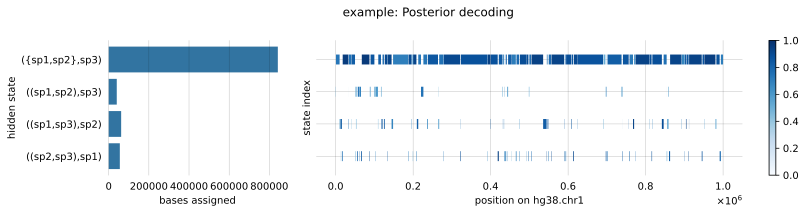

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True, 
                             width_ratios=(1, 3))

sns.barplot(total_bp, x='total_bp', y='most_likely_state', ax=axes[0])

axes[0].set_xlabel('bases assigned')
axes[0].set_ylabel('hidden state')
axes[0].set_yticks([0, 1, 2, 3])
axes[0].set_yticklabels(['({sp1,sp2},sp3)', '((sp1,sp2),sp3)', '((sp1,sp3),sp2)', '((sp2,sp3),sp1)'])

cmap = plt.get_cmap('Blues')
# if windowed:
for seg in post_decoding.itertuples():
    axes[1].hlines(seg.most_likely_state, seg.genome_start, seg.genome_end,
                    lw=10, color=cmap(seg.mean_prob))
axes[1].set_xlabel(f"position on {vit['chrom'].iloc[0]}")
# else:
#     largest_block = vit.groupby('Block_idx')['length'].sum().idxmax()
#     block = vit[vit['Block_idx'] == largest_block]
#     for seg in block.itertuples():
#         axes[1].hlines(seg.most_likely_state, seg.position_start, seg.position_end,
#                         lw=3, color='C0')
#     axes[1].set_xlabel(f'position in block {largest_block}')
axes[1].set_ylabel('state index')

norm = plt.Normalize(0, 1)
sm = plt.cm.ScalarMappable(cmap="RdBu", norm=norm)
sm.set_array([])

# Remove the legend and add a colorbar
#axes[1].get_legend().remove()
#axes[1].figure.colorbar(sm)

import matplotlib
fig.colorbar(matplotlib.colorizer.ColorizingArtist(matplotlib.colorizer.Colorizer(norm=norm, cmap=cmap)), ax=axes[1])

fig.suptitle(f'{name}: Posterior decoding')
fig.tight_layout()

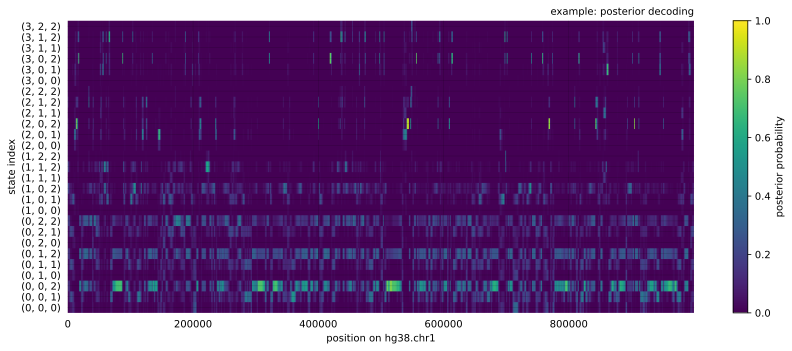

In [15]:

step = 1 #max(1, probs.shape[1] // 2000)
plt.figure(figsize=(12, 5))
plt.imshow(probs[:, ::step], aspect='auto', origin='lower',
            cmap='viridis', vmin=0, vmax=1, 
            interpolation='nearest')
plt.colorbar(label='posterior probability')
plt.xlabel(xlabel + (f' (every {step} bp)' if step > 1 else ''))
plt.yticks(states.state_idx, states.shorthand_name)
plt.ylabel('state index')
plt.title(f'{name}: posterior decoding')
plt.tight_layout()

In [30]:
df = pd.DataFrame(probs)
df['a'], df['b'], df['c']= zip(*states.shorthand_name.apply(eval))
# df = df.loc[df.a > 1]
df.set_index(['a', 'b', 'c'], inplace=True)
df = df.groupby('a').agg('sum').T
probs = df.to_numpy().T

<Axes: >

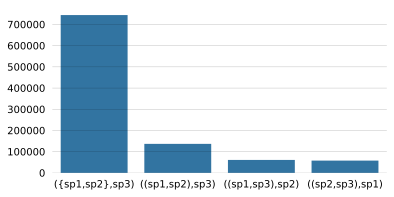

In [31]:
fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(x=['({sp1,sp2},sp3)', '((sp1,sp2),sp3)', '((sp1,sp3),sp2)', '((sp2,sp3),sp1)'], y=np.sum(probs, axis=1), ax=ax)

Text(1.0, 1.0, 'example: posterior decoding')

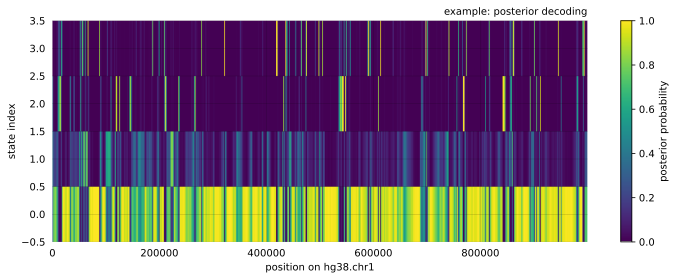

In [32]:
step = 1 #max(1, probs.shape[1] // 2000)
plt.figure(figsize=(12, 4))
plt.imshow(probs[:, ::step], aspect='auto', origin='lower',
            cmap='viridis', vmin=0, vmax=1, 
            interpolation='nearest')
plt.colorbar(label='posterior probability')
plt.xlabel(xlabel + (f' (every {step} bp)' if step > 1 else ''))
plt.ylabel('state index')
plt.title(f'{name}: posterior decoding')

Text(1.0, 1.0, 'example: posterior decoding')

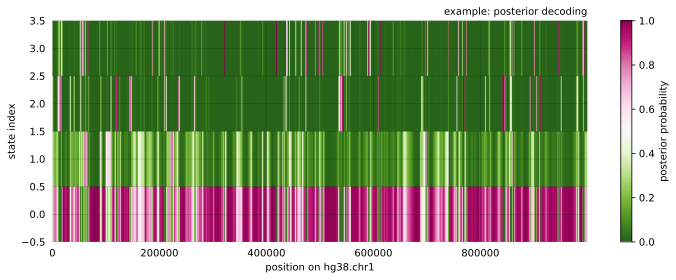

In [160]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

norm = colors.TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)


step = 1 #max(1, probs.shape[1] // 2000)
plt.figure(figsize=(12, 4))
plt.imshow(probs[:, ::step], aspect='auto', origin='lower',
            cmap='PiYG_r', norm=norm,
            interpolation='nearest')
plt.colorbar(label='posterior probability')
plt.xlabel(xlabel + (f' (every {step} bp)' if step > 1 else ''))
plt.ylabel('state index')
plt.title(f'{name}: posterior decoding')

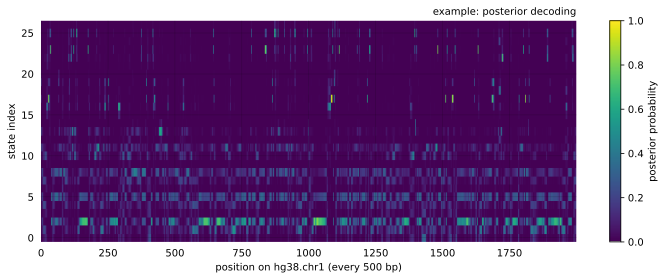

In [19]:
for analysis in analyses:
    name = analysis.name
    windowed = (analysis / 'concat' / f'{name}.posterior.csv').exists()
    if windowed:
        post = pd.read_csv(analysis / 'concat' / f'{name}.posterior.csv')
        prob_cols = [c for c in post.columns if c.startswith('prob_state_')]
        post['genome_pos'] = post['block_start'] + post['position_idx']
        post = post.sort_values('genome_pos')
        probs = post[prob_cols].to_numpy().T
        xlabel = f"position on {post['chrom'].iloc[0]}"
    else:
        post = pd.read_csv(analysis / 'posterior' / f'{name}.posterior.csv')
        prob_cols = [c for c in post.columns if c.startswith('prob_state_')]
        block_col = post.columns[0]
        largest_block = post[block_col].value_counts().idxmax()
        probs = post[post[block_col] == largest_block][prob_cols].to_numpy().T
        xlabel = f'position in block {largest_block}'

    step = max(1, probs.shape[1] // 2000)
    plt.figure(figsize=(12, 4))
    plt.imshow(probs[:, ::step], aspect='auto', origin='lower',
               cmap='viridis', vmin=0, vmax=1, interpolation='nearest')
    plt.colorbar(label='posterior probability')
    plt.xlabel(xlabel + (f' (every {step} bp)' if step > 1 else ''))
    plt.ylabel('state index')
    plt.title(f'{name}: posterior decoding')
    plt.show()